# 🏪 Product Success Prediction System

### Overview
Stocking a shop is risky. Some products sell fast, others gather dust. This project uses **Machine Learning** to help shopkeepers predict if a product will be a **Success** or a **Failure** based on pre-stocking data like price, category, and historical trends.

---

## Install Dependencies


In [38]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

##   Import Libraries


In [39]:
import warnings
warnings.filterwarnings('ignore') # Silence unnecessary warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib

# Setting global visualization style
sns.set_palette("viridis")
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Environment Setup Complete!")

✅ Environment Setup Complete!


##  Load the Dataset


In [40]:
df = pd.read_csv('product_success_dataset-2.csv')
print(f"Dataset Dimension: {df.shape}")
df.head()


Dataset Dimension: (1000, 13)


,Category,Seasonality,Region,Price,Discount,Marketing_Budget,Advertising_Channel,Target_Age_Group,Brand_Reputation,Competition_Level,Product_Quality_Rating,Previous_Product_Success,Success
0,Beauty,Summer,East,15.76,40,20000,TV,Seniors,Medium,Medium,3.7,Yes,1
1,Toys,Autumn,West,20.13,50,50000,Influencer,Seniors,Medium,Medium,1.5,Yes,0
2,Furniture,Spring,South,11.21,20,50000,NaN,Kids,Medium,High,1.5,No,0
3,Beauty,Spring,West,414.12,25,500,NaN,Teens,High,High,2.6,No,0
4,Food,Spring,West,1699.99,15,10000,TV,Adults,Low,Low,3.6,Yes,1


In [41]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Category                  1000 non-null   str    
 1   Seasonality               1000 non-null   str    
 2   Region                    1000 non-null   str    
 3   Price                     1000 non-null   float64
 4   Discount                  1000 non-null   int64  
 5   Marketing_Budget          1000 non-null   int64  
 6   Advertising_Channel       796 non-null    str    
 7   Target_Age_Group          1000 non-null   str    
 8   Brand_Reputation          1000 non-null   str    
 9   Competition_Level         1000 non-null   str    
 10  Product_Quality_Rating    1000 non-null   float64
 11  Previous_Product_Success  1000 non-null   str    
 12  Success                   1000 non-null   int64  
dtypes: float64(2), int64(3), str(8)
memory usage: 101.7 KB


,Price,Discount,Marketing_Budget,Product_Quality_Rating,Success
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,520.562680,21.675000,12242.50000,2.943300,0.534000
std,684.807205,16.108347,16535.74536,1.136586,0.499092
min,4.970000,0.000000,500.00000,1.000000,0.000000
25%,29.915000,10.000000,1000.00000,1.975000,0.000000
50%,48.315000,20.000000,5000.00000,2.900000,1.000000
75%,422.052500,30.000000,20000.00000,3.900000,1.000000
max,1717.720000,50.000000,50000.00000,5.000000,1.000000


In [42]:
print("Missing values summary:")
print(df.isnull().sum())


Missing values summary:
Category                      0
Seasonality                   0
Region                        0
Price                         0
Discount                      0
Marketing_Budget              0
Advertising_Channel         204
Target_Age_Group              0
Brand_Reputation              0
Competition_Level             0
Product_Quality_Rating        0
Previous_Product_Success      0
Success                       0
dtype: int64


In [43]:
# Check all columns before dropping
print("Before dropping:", df.columns.tolist())
print("Shape before:", df.shape)

# Drop all unwanted columns
df = df.drop(columns=[
    'Marketing_Budget',
    'Advertising_Channel',
    'Target_Age_Group',
    'Brand_Reputation',
    'Competition_Level',
    'Product_Quality_Rating',
    'Previous_Product_Success'
])

# Confirm what is left
print("\nAfter dropping:", df.columns.tolist())
print("Shape after:", df.shape)

Before dropping: ['Category', 'Seasonality', 'Region', 'Price', 'Discount', 'Marketing_Budget', 'Advertising_Channel', 'Target_Age_Group', 'Brand_Reputation', 'Competition_Level', 'Product_Quality_Rating', 'Previous_Product_Success', 'Success']
Shape before: (1000, 13)

After dropping: ['Category', 'Seasonality', 'Region', 'Price', 'Discount', 'Success']
Shape after: (1000, 6)


## Exploratory Data Analysis (EDA)


### 4.1 Univariate Analysis


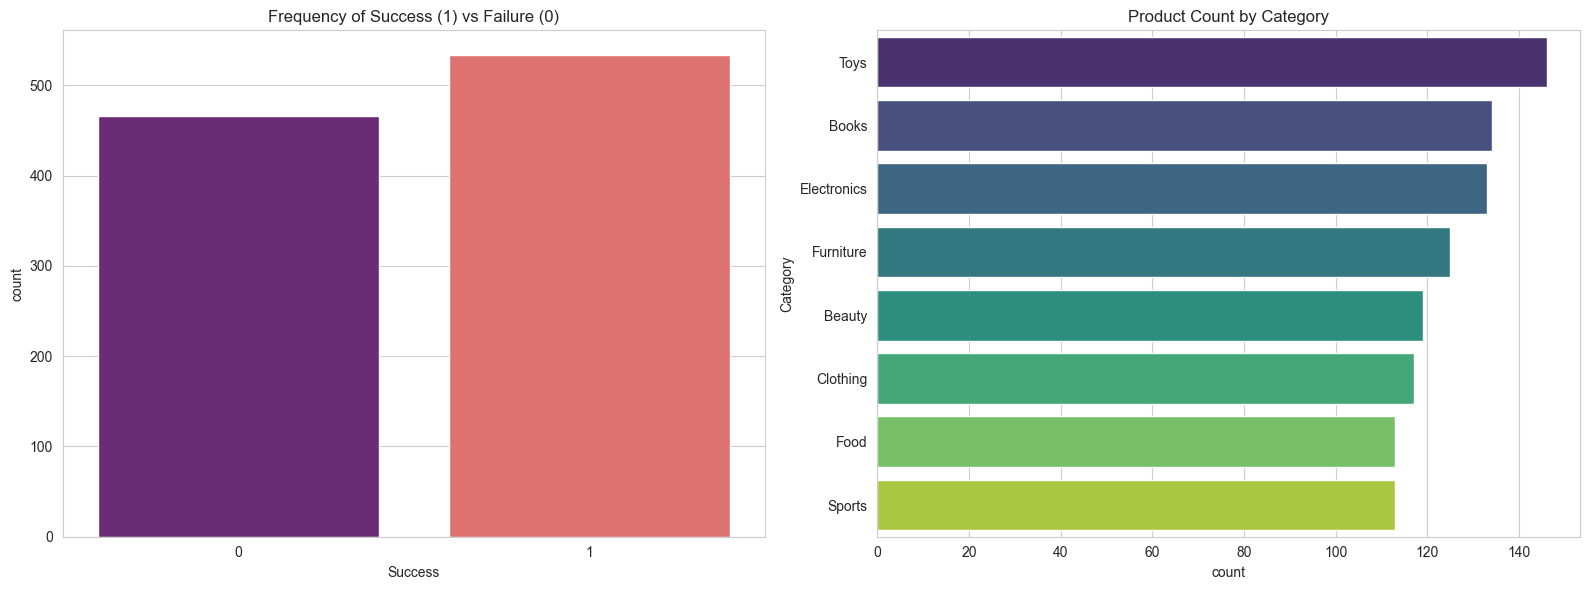

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Target Variable Distribution
sns.countplot(x='Success', data=df, ax=ax[0], palette='magma')
ax[0].set_title('Frequency of Success (1) vs Failure (0)')

# Category Distribution
sns.countplot(y='Category', data=df, ax=ax[1], order=df['Category'].value_counts().index, palette='viridis')
ax[1].set_title('Product Count by Category')

plt.tight_layout()
plt.show()

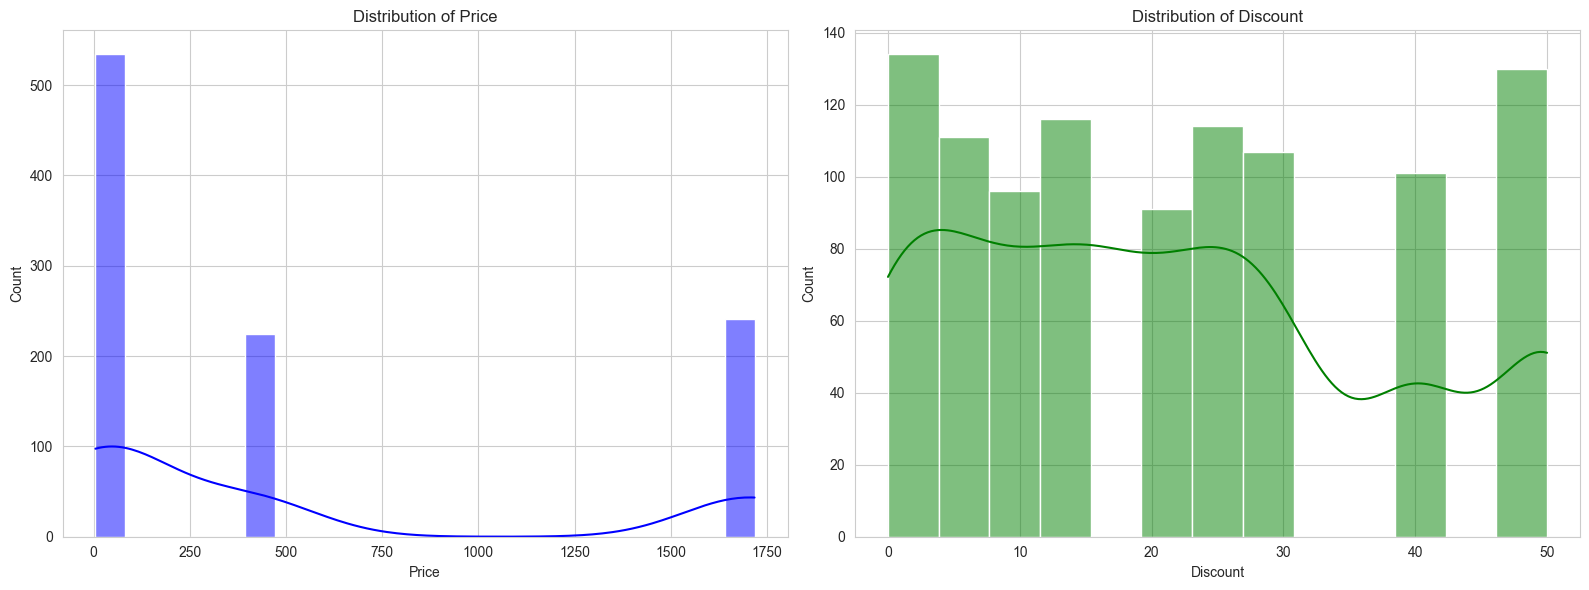

In [23]:
# Distribution of Numeric Features
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Price'], kde=True, color='blue', ax=ax[0])
ax[0].set_title('Distribution of Price')

sns.histplot(df['Discount'], kde=True, color='green', ax=ax[1])
ax[1].set_title('Distribution of Discount')

plt.tight_layout()
plt.show()

### 4.2 Bivariate Analysis


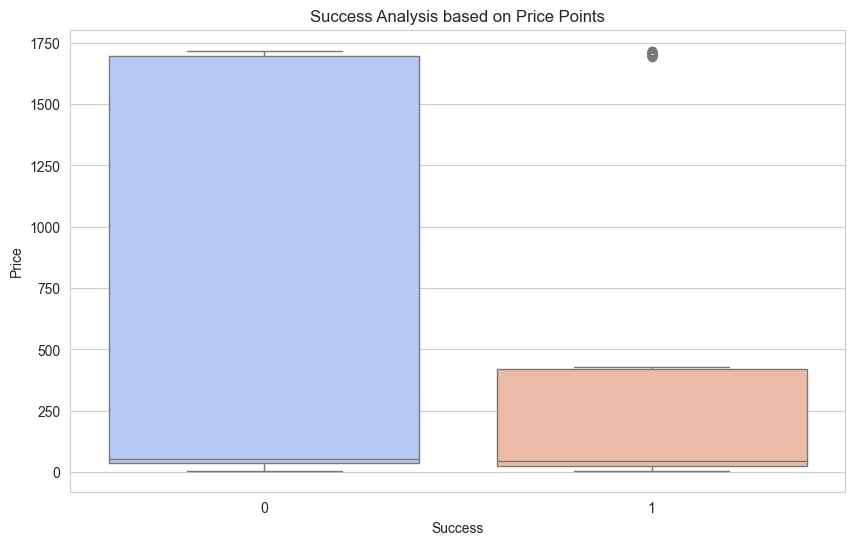

In [47]:
# Price vs Success
plt.figure(figsize=(10, 6))
sns.boxplot(x='Success', y='Price', data=df, palette='coolwarm')
plt.title('Success Analysis based on Price Points')
plt.show()

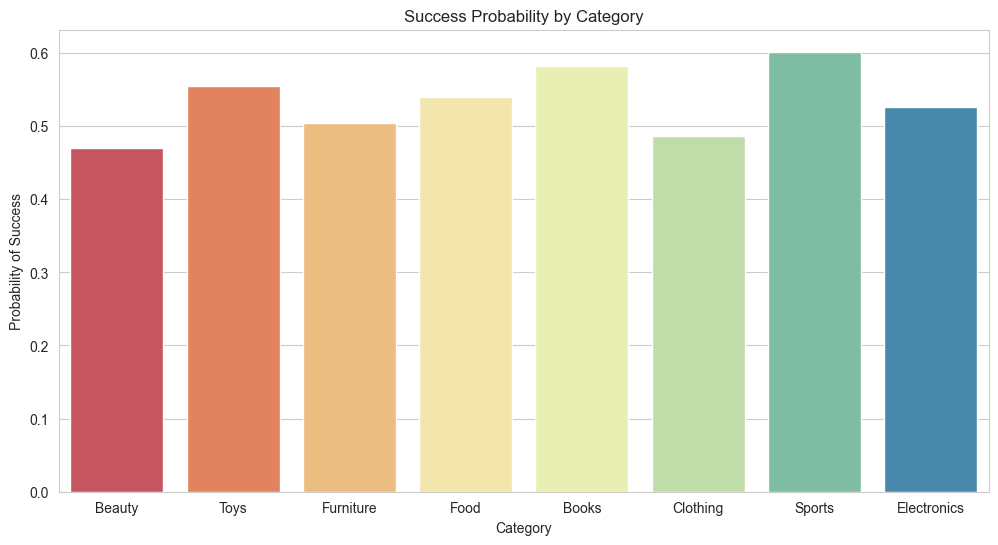

In [48]:
# Category vs Success Rank
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Success', data=df, ci=None, palette='Spectral')
plt.title('Success Probability by Category')
plt.ylabel('Probability of Success')
plt.show()

### 4.3 Multivariate Analysis


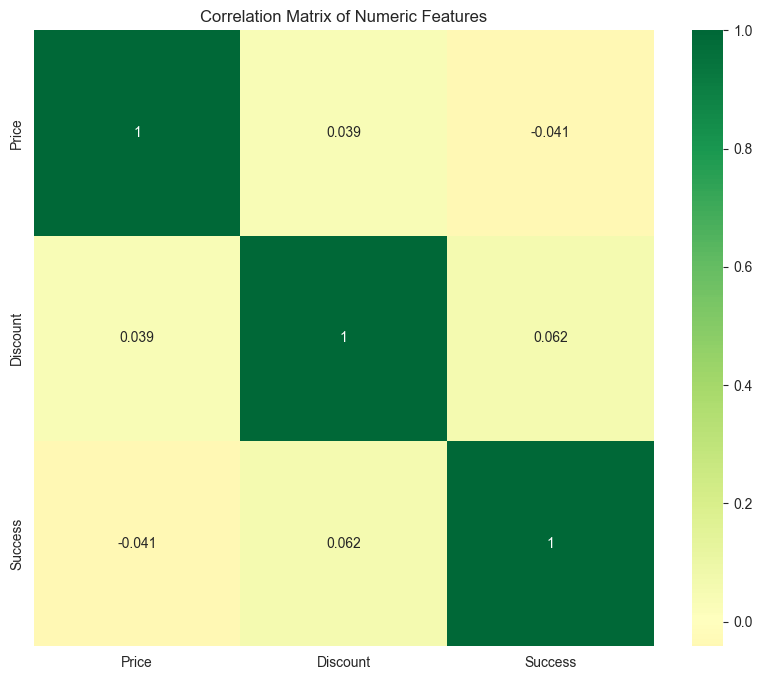

In [49]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

##  Data Cleaning & Outlier Analysis


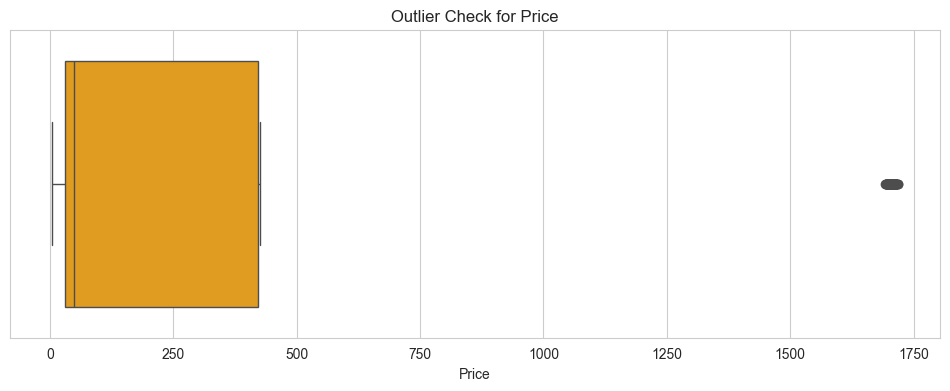

Observation: High price points are visible as outliers on the right side.


In [50]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['Price'], color='orange')
plt.title('Outlier Check for Price')
plt.show()

print("Observation: High price points are visible as outliers on the right side.")

In [51]:
import numpy as np

# Step 1: Calculate IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 2: Find Outliers
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))
print("Outlier Percentage:", (len(outliers) / len(df)) * 100)

# Step 3: Apply Capping
df['Price'] = df['Price'].clip(lower_bound, upper_bound)

print("✅ Outliers capped successfully.")

Lower Bound: -558.29125
Upper Bound: 1010.25875
Number of Outliers: 241
Outlier Percentage: 24.099999999999998
✅ Outliers capped successfully.


##  Encoding Categorical Variables
Converting text categories (Region, Category, Seasonality) into numbers using **One-Hot Encoding**.

In [52]:
features = ['Category', 'Seasonality', 'Region', 'Price', 'Discount']
X = df[features]
y = df['Success']

# Create dummies
X = pd.get_dummies(X, columns=['Category', 'Seasonality', 'Region'], drop_first=False)
model_columns = list(X.columns)
print(f"Encoded Features count: {len(model_columns)}")
X.head()

Encoded Features count: 18


,Price,Discount,Category_Beauty,Category_Books,Category_Clothing,Category_Electronics,Category_Food,Category_Furniture,Category_Sports,Category_Toys,Seasonality_Autumn,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Region_East,Region_North,Region_South,Region_West
0,15.76000,40,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
1,20.13000,50,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True
2,11.21000,20,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
3,414.12000,25,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,1010.25875,15,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True


## ⚖️ Step 7: Scaling / Normalization
Scaling Price and Discount to have a mean of 0 and standard deviation of 1. This prevents 'Price' from dominating the model just because its values are larger.

In [53]:
scaler = StandardScaler()
X[['Price', 'Discount']] = scaler.fit_transform(X[['Price', 'Discount']])
print("✅ Scaling Completed.")
X.describe()[['Price', 'Discount']]

✅ Scaling Completed.


,Price,Discount
count,1.000000e+03,1.000000e+03
mean,-3.552714e-18,-3.552714e-17
std,1.000500e+00,1.000500e+00
min,-8.696886e-01,-1.346249e+00
25%,-8.073884e-01,-7.251422e-01
50%,-7.614344e-01,-1.040354e-01
75%,1.719752e-01,5.170714e-01
max,1.641021e+00,1.759285e+00


## 🤖 Step 8: Model Training
Splitting data into 80% Training and 20% Testing, then training the **Logistic Regression** model.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy Score: 52.00%


## 📉 Step 9: Performance Analysis
Analyzing the model using a Confusion Matrix.

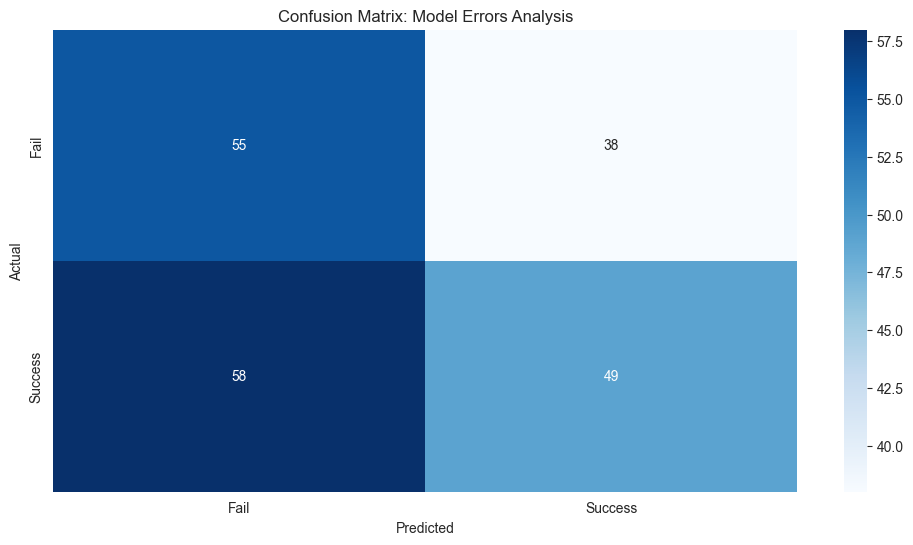

Report:
              precision    recall  f1-score   support

           0       0.49      0.59      0.53        93
           1       0.56      0.46      0.51       107

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.53      0.52      0.52       200



In [37]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'])
plt.title('Confusion Matrix: Model Errors Analysis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Report:")
print(classification_report(y_test, y_pred))